# import

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import sys
sys.path.append("../General_Functions/")
from BasicData import *
from Flow_functions import * # import flow functions, Information to the agent
from Geometric_functions import * # Import rotation from euler angles
from Evolution_Traj import * # Import time integration for trjectories
from Time_Int_Traj import * # Import evolution function
from BasicData import *  # Nagents, R0, V
from Strategies import * # Import strategies, Braitenberg or Triangulation
from Strategies_Evolution_StrategyNoise import * # Import strategies Evolution, Braitenberg or Triangulation
from Flow_functions import * # Import flow functions: stokeslet, grads, strains ... 


In [2]:
# Integrate numerically the angular dynamics of each strategy
# Calculate the scalar product between t at the end of the evolution
# and the real source position

    
def EvolutionStrategyNoise(Grad, Intensity):

    # Function to evaluate the scalar product between t at the end of the evolution
    # and the real source position
    #input:
    # Gradient (source flow measured)
    #output:
    # dot product as a 2D map
    # variance of dot product as 2D map
    
    # Noise intensity   
    t0_T, t1_T, t2_T = np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials))
    # Resulting dot products
    # DotProduct_T_not = np.zeros((NPoints, NPoints, NTrials))
    DotProduct_T = np.zeros((NPoints, NPoints, NTrials))
    
    for k in range(NPoints):
        for i in range(NPoints):
            AgentPosition =  np.array([z[k], x[i], 0.])
            OptimalDirection = -np.copy(AgentPosition/np.linalg.norm(AgentPosition))

            for trials_i in range(NTrials):
                # Random orientation of agent axis
                alpha, beta, gamma = (2 * np.random.rand(3) - 1) * np.pi
                RotationMatrix = Rotation(alpha, np.abs(beta), gamma)

                n_T = np.dot(RotationMatrix,[0, 1, 0])
                b_T = np.dot(RotationMatrix,[0, 0, 1])
                t_T = np.dot(RotationMatrix,[1, 0, 0])

                # Time integration of strategies
                for time in range(Duration):
                    n_T, b_T, t_T = Evolution_Triangulation(n_T, b_T, t_T, AntennaeLength, AgentPosition, Grad, e3, dt, roll, Intensity)

                t0_T[k, i, trials_i], t1_T[k, i, trials_i], t2_T[k, i, trials_i] = t_T
                DotProduct_T[k, i, trials_i] = np.dot(t_T, OptimalDirection)

    return DotProduct_T,\
        t0_T, t1_T

In [8]:
# Data
NPoints = 40 # Grid number of points per axis
Duration = 455 # Number of timesteps of the numerical integration
NTrials = 20 # Number of trial x point

AntennaeLength = .01 # Sensors distance, on antennae
x = np.linspace(1.0, 30, NPoints) # x axis
z = np.linspace(1.0, 30, NPoints) # z axis

e3 = np.array([1, 0, 0]) # Source flow axis of symmetry, scheme zxy
dt = .1 # Timesteps 
roll = .2 # Roll Intensity
NameStrategies = ["T"] # , "T", "I"] 

In [9]:
# Calculate and save data

# Information flow \
GradName = ['GradientStresslet'] # 'ShearQuadruplet', 'GradientQuadruplet', 
Grads =  [GradientStresslet] # ShearQuadruplet, GradientQuadruplet

for grads_i, Grad in enumerate(Grads):
    Intensity = 0.5
    # t axis for Triangulation strategy absence of roll
    t0_T, t1_T = np.zeros((NPoints, NPoints, NTrials)), np.zeros((NPoints, NPoints, NTrials))

    # Evaluate the strategy 2D map, vector P 
    Avg_P_T = np.zeros((NPoints, NPoints, NTrials))

    Avg_P_T, t0_T, t1_T = EvolutionStrategyNoise(Grad, Intensity)
    # Set up figure and image grid

    AllAvg = [Avg_P_T] # _not, Avg_P_T, Avg_P_I]
    Allt0 = [t0_T] #_not, t0_T, t0_I]
    Allt1 = [t1_T] # _not, t1_T, t1_I]

    for i, strat_name in enumerate(NameStrategies):
        np.savetxt("Data_StrategyNoise/"+str(GradName[grads_i])+"_Avg_"+str(strat_name)+"_Intensity_"+str(np.round(Intensity, 5))+"_radius_30_noi1.txt", np.mean(AllAvg[i], axis = 2), delimiter = ',')
        np.savetxt("Data_StrategyNoise/"+str(GradName[grads_i])+"_t0_"+str(strat_name)+"_Intensity_"+str(np.round(Intensity, 5))+"_radius_30_noi1.txt", np.mean(Allt0[i], axis = 2), delimiter = ',')
        np.savetxt("Data_StrategyNoise/"+str(GradName[grads_i])+"_t1_"+str(strat_name)+"_Intensity_"+str(np.round(Intensity, 5))+"_radius_30_noi1.txt", np.mean(Allt1[i], axis = 2), delimiter = ',')

#plt.show()

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


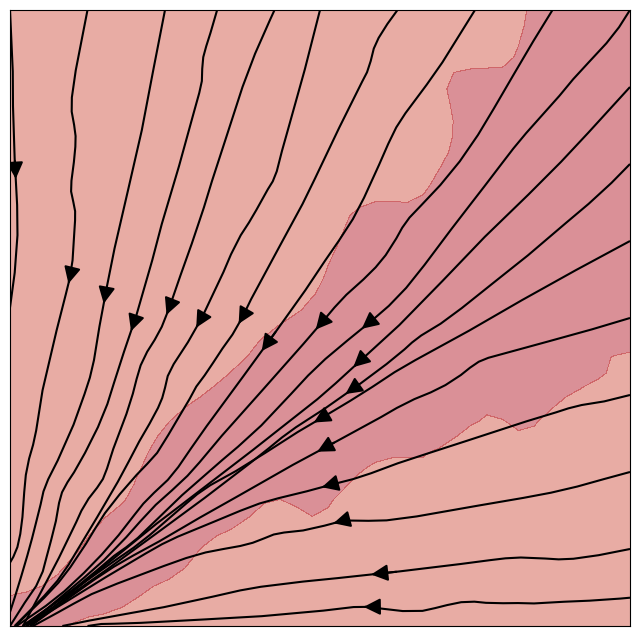

In [10]:
# Plot data from Save 

import scipy.ndimage as ndimage # import to smooth plots

for grads_i, Grad in enumerate(GradName):
    for i, strat_name in enumerate(NameStrategies):
        Intensity = 0.5
        # Extract data from saved file
        with open("Data_StrategyNoise/"+str(GradName[grads_i])+"_Avg_"+str(strat_name)+"_Intensity_"+str(np.round(Intensity, 5))+"_radius_30_noi1.txt", 'r') as the_file:
            Avg = np.array([np.asarray(each_line.split(",")).astype(float) for each_line in the_file]) 


        with open("Data_StrategyNoise/"+str(GradName[grads_i])+"_t0_"+str(strat_name)+"_Intensity_"+str(np.round(Intensity, 5))+"_radius_30_noi1.txt", 'r') as the_file:
            t0 = np.array([np.asarray(each_line.split(",")).astype(float) for each_line in the_file]) 
        with open("Data_StrategyNoise/"+str(GradName[grads_i])+"_t1_"+str(strat_name)+"_Intensity_"+str(np.round(Intensity, 5))+"_radius_30_noi1.txt", 'r') as the_file:

            t1 = np.array([np.asarray(each_line.split(",")).astype(float) for each_line in the_file]) 

        # Plot parameters
        CMAP = 'RdBu_r' #'spring'
        STREAMCOLOR = 'black'
        MIN_VALUE = -1
        MAX_VALUE = 1
        
        fig1, axs = plt.subplots(nrows=1, ncols=1, figsize=(8,8), sharex='col', sharey='row')
        ax1 = axs
        X, Z = np.meshgrid(x, z, indexing='xy')

        # Add data to image grid
        levels = np.linspace(-1, 1.00001, 14)

        Avg = ndimage.gaussian_filter(Avg, sigma=1.5, order=0)
        im = ax1.contourf(X, Z, Avg, cmap = CMAP, levels = levels, vmin= MIN_VALUE, vmax = MAX_VALUE, alpha = 0.5)
        ax1.streamplot(X, Z, t1, t0, color = STREAMCOLOR,  density = .3,  arrowsize = 2.5, broken_streamlines=False)
        #PlotCircles(ax1, .5)
        ax1.set_xlim([1.0, 30])
        ax1.set_ylim([1.0, 30])
        ax1.set_xticks([])
        ax1.set_yticks([])



        # plt.colorbar(im, ax = axs, ticks = np.arange(-1, 1.1, 0.5), location= 'bottom')
        # Uncomment to save
        plt.savefig("Plots_StrategyNoise/"+str(GradName[grads_i])+"_"+str(strat_name)+"_radius_30.eps", format = 'eps', bbox_inches='tight')
        plt.savefig("Plots_StrategyNoise/"+str(GradName[grads_i])+"_"+str(strat_name)+"_radius_30.pdf", bbox_inches='tight')
        plt.show()

False